In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# %matplotlib widget
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fft2, ifft, ifft2, fftfreq, fftshift
import pandas as pd
import sympy as sy
from sympy import sin, exp, cos
from IPython.display import display, Markdown
from tqdm import tqdm

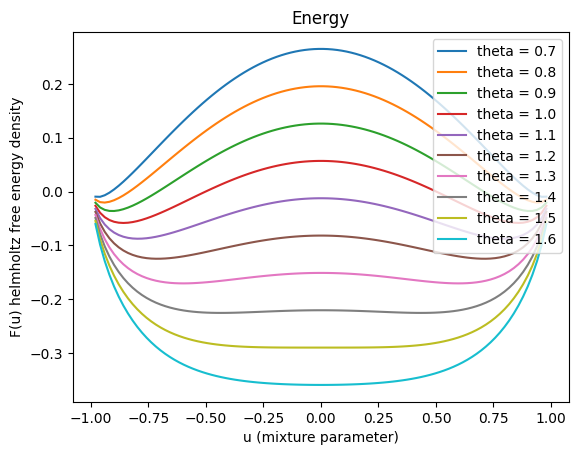

In [5]:
#logartihmic potential
temperatur_thetas = np.arange(0.7,1.7,0.1)
u = np.linspace(-1,1,100)
critical_temperature = 1.5

def log_potential(u,theta):
    l1 = (critical_temperature/2)*(1-u**2)
    l2 = (theta/2)*((1-u)*np.log((1-u)/2)+(1+u)*np.log((1+u)/2))
    return l1 + l2

for theta in temperatur_thetas:
    y_vals = log_potential(u,theta)
    plt.plot(u,y_vals, label = f'theta = {np.round(theta,2)}')
    plt.legend()

plt.title("Energy")
plt.xlabel("u (mixture parameter)")
plt.ylabel("F(u) helmholtz free energy density")
plt.show()

Ved lavere temperaturer enn kritisk temperatur $\theta_c$, ser vi at minimumspunktene er separert av en potensialbarriere. Dette beskriver en tilstand hvor energien minimeres dersom blandingen separeres i to forskjellige faser. For høyere temperaturer forsvinner potensialbarrieren, og vi får en konveks funksjon. Nå minimeres energien dersom vi har en perfekt blanding mellom de to fasene

Vi skal vise at Cahn–Hilliard-likningen er invariant under transformasjonen  
$ u(x,t) \mapsto -u(x,t) $.  
Det vil si at hvis $ u(x,t) $ er en løsning, så er også $ -u(x,t) $ en løsning.

#### Cahn–Hilliard-ligningen

$\partial_t u - \nabla \cdot (M\nabla(f(u)-\kappa\Delta u)) = g$

#### Vil vise at -u(x,t) er en løsning dersom u(x,t) er en løsning.

Den deriverte er en lineær operator. Dette betyr at $\partial_t (-u) = -\partial_t u$. 

$\Delta u = \partial^2_x u + \partial^2_y u$, som er en operator som kun består av deriverte og addisjon, som også er lineære operatorer $\Rightarrow$ Laplace operatoren er lineær og $\Delta(-u) = -\Delta u$.

$\Delta^2 u = \Delta(\Delta(u))$, som er en operator som kun består av Laplace operatoren, som er lineær $\Rightarrow$ Den harmoniske operatoren er lineær og $\Delta^2(-u) = -\Delta^2 u$.

$f(u) = -\theta_c u + \frac{\theta}{2}\ln{\frac{1+u}{1-u}} \Rightarrow f(-u) = -\theta_c (-u) + \frac{\theta}{2}\ln{\frac{1+(-u)}{1-(-u)}} = \theta_c u + \frac{\theta}{2}\ln{\frac{1-u}{1+u}} = \theta_c u - \frac{\theta}{2}\ln{\frac{1+u}{1-u}} = -(-\theta_c u + \frac{\theta}{2}\ln{\frac{1+u}{1-u}}) \Rightarrow f(-u) = -f(u)$

Cahn-Hilliard-likningen består kun av operatorer og funksjoner som oppfyller at $ u(x,t) \mapsto -u(x,t) \Rightarrow $ Dersom $u(x,t)$ er en løsning er også $-u(x,t)$ også en løsning.

Vi skal vise at systemets masse forblir konstant ved endring av tid. Altså vi vil vise at:

$\frac{d}{dt}\int_{\Omega} u(\mathbf{x},t) \,d\mathbf{x} = 0$

Det kan vises at: $\frac{d}{dt}\int_{\Omega} u(\mathbf{x},t) \,d\mathbf{x} = \int_{\Omega} \frac{u(\mathbf{x},t)}{dt} \,d\mathbf{x}$

Vi vet at $\partial_t u = M\Delta \mu \Rightarrow \int_{\Omega} M\Delta \mu \,d\mathbf{x} = 0$. Vi antar videre at $M = 1$

Ved bruk av divergens teoremet kan vi si at:

$\int_{\Omega} \Delta \mu \,d\mathbf{x} = \oint_{\partial \Omega} \nabla\mu \cdot \mathbf{\hat{N}} \,ds$

$\oint_{\partial \Omega} (\frac{\partial \mu}{\partial x},\frac{\partial \mu}{\partial y}) \cdot \hat{\mathbf{N}} \,ds = \int_{0}^{L_y} \nabla \mu \cdot (0,-1) \,dy + \int_{0}^{L_x} \nabla \mu \cdot (-1,0) \,dx + \int_{0}^{L_y} \nabla \mu \cdot (0,1) \,dy + \int_{0}^{L_x} \nabla \mu \cdot (1,0) \,dx$

$\int_{0}^{L_y} -\frac{\partial \mu}{dy} \,dy + \int_{0}^{L_x} -\frac{\partial \mu}{dx} \,dx + \int_{0}^{L_y} \frac{\partial \mu}{dy} \,dy + \int_{0}^{L_x} \frac{\partial \mu}{dy} \,dx = 0$. Herved vist.

$\frac{d}{dt}\int_{\Omega} u(\mathbf{x},t) \,d\mathbf{x} = 0 \Rightarrow \int_{\Omega} u(\mathbf{x},t) = konstant$. Massen er konstant for alle tidspunkt.


In [6]:
def biharmonic_solver(Lx,Ly,Nx,Ny, F, c, mean):
    F_hat = fft2(F)
    kx = fftfreq(Nx, d=Lx/Nx) * 2 * np.pi
    ky = fftfreq(Ny, d=Ly/Ny) * 2 * np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    K2 = KX**2+KY**2
    KfourierSpace = (K2**2 + c)
    KfourierSpace[0,0] = 1

    u_hat = F_hat/KfourierSpace
    u_hat[0,0] = mean

    U = ifft2(u_hat).real

    return U

In [ ]:
#parameters:
Nx1 = np.array([4,8,15,16,20,32])
Ny1 = 2*Nx1

k = np.arange(0,10)
Nx2 = 4+4*k
Ny2 =2*Nx2

In [8]:
#manufacture solutions: 
def manufacture_solution_biharmonic(u_string, c):
    x, y = sy.symbols('x y')
    u_symbolic = eval(u_string)

    laplace = lambda u: sy.diff(u, x, 2) + sy.diff(u, y, 2)
    
    #beregner dobbel laplace på funksjonen (laplace^2)
    firstLaplace = laplace(u_symbolic)
    biharmonic = laplace(firstLaplace)
    f_symbolic = biharmonic + c*u_symbolic
    f_symbolic = sy.simplify(f_symbolic)

    u = sy.lambdify((x, y), u_symbolic, modules='numpy')
    f = sy.lambdify((x, y), f_symbolic, modules='numpy')

    return u,f

In [9]:
u1_string = 'sin(8*(x-1))*cos(4*y)'
u1,f1 = manufacture_solution_biharmonic(u1_string, c = 1)

u2_string = 'exp(sin(x)**2+cos(2*y))'
u2,f2 = manufacture_solution_biharmonic(u2_string, c = 0)

In [10]:
def compute_errors(f,NX,NY,u,c):
    errors = []
    eocs = []
    for i in range(len(NX)):
        Lx = 2*np.pi
        Ly = 4*np.pi
        Nx = NX[i]
        Ny = NY[i]
        x = np.linspace(0,Lx,Nx, endpoint=False)
        y = np.linspace(0,Ly,Ny, endpoint=False)
        X,Y = np.meshgrid(x,y, indexing="ij")

        F = f(X,Y)
        U_ex = u(X,Y)
        U = biharmonic_solver(Lx,Ly,Nx,Ny,F,c, mean = 0)
        U += np.mean(U_ex)
        U_err = U - U_ex
        error = np.linalg.norm(U_err, np.inf)

        #append stuff
        errors.append(error)

        #convergences
        if len(errors) > 1:
            h_now = Lx / NX[i]
            h_prev = Lx / NX[i-1]
            eoc = np.log(errors[-1] / errors[-2]) / np.log(h_now / h_prev)
            eocs.append(eoc)
        else:
            eocs.append("Not yet...")

    return errors,eocs
        
errors1, eocs1 = compute_errors(f1,Nx1,Ny1,u1,c=1)
errors2, eocs2 = compute_errors(f2,Nx2,Ny2,u2,c=0)

In [21]:
df1 = pd.DataFrame({
    'Nx': Nx1,
    'Ny': Ny1,
    'Error': errors1,
    'EOC': eocs1
})

df2 = pd.DataFrame({
    'Nx': Nx2,
    'Ny': Ny2,
    'Error': errors2,
    'EOC': eocs2
})

display(df1)
display(df2)

,Nx,Ny,Error,EOC
0,4,8,1.818989e-12,Not yet...
1,8,16,3.784353e+02,-47.563903
2,15,30,9.827684e+00,5.807813
3,16,32,7.863653e-14,502.942163
4,20,40,6.159517e-13,-9.224252
5,32,64,1.001514e-12,-1.034246


,Nx,Ny,Error,EOC
0,4,8,9.573099e+01,Not yet...
1,8,16,8.456927e+01,0.178852
2,12,24,1.123358e+01,4.978638
3,16,32,3.294907e-01,12.267412
4,20,40,1.254177e-02,14.647448
5,24,48,7.612873e-04,15.367403
6,28,56,4.102912e-05,18.947233
7,32,64,2.124529e-06,22.172552
8,36,72,9.783264e-08,26.133196
9,40,80,4.265664e-09,29.732775
